# Multimodal Document Summarizer and RAG Application

This notebook shows a complete, end to end pipeline that:

1. Reads a PDF file and pulls out three kinds of content: plain text, tables and images.
2. Uses a language model to write a short summary of every table, every block of text and every image.
3. Stores those summaries inside a vector database (Chroma) so they can be searched by meaning, not just by keyword.
4. Builds a Retrieval Augmented Generation (RAG) chain that finds the most relevant pieces of content for a question and asks a multimodal language model to answer using that content.

This version of the notebook has been rewritten to run on a local machine inside VS Code (or any local Jupyter environment). The original notebook was written for Google Colab, so every Colab only piece (Colab file paths under `/content`, `google.colab.userdata`, Colab specific shell commands) has been replaced with the local equivalent, and every step now has a markdown explanation plus inline comments so a beginner can follow along.


## 1. Before you start: system requirements

The Python package `unstructured` needs two pieces of software that are **not** Python packages: `poppler` (used to read PDF pages) and `tesseract` (used for OCR, meaning it reads text that only exists as an image inside the PDF).

Because these are system tools rather than Python packages, they must be installed once on your computer using your operating system's own package manager, **not** with `pip`. Open a terminal (Command Prompt, PowerShell or a Mac/Linux terminal) and run the command that matches your operating system.

### Windows
Install both tools with the Chocolatey package manager:
```
choco install poppler
choco install tesseract
```
If you do not have Chocolatey, you can instead download the Poppler binaries and the Tesseract installer directly and add both to your system `PATH`.

### macOS
Install both tools with Homebrew:
```
brew install poppler
brew install tesseract
```

### Linux (Debian or Ubuntu based)
```
sudo apt-get update
sudo apt-get install -y poppler-utils
sudo apt-get install -y libleptonica-dev tesseract-ocr libtesseract-dev python3-pil tesseract-ocr-eng tesseract-ocr-script-latn
```

Once these system tools are installed and available on your `PATH`, restart VS Code so the new `PATH` is picked up, then continue with the Python package installation below.


## 2. Install the required Python packages

The cell below installs every Python package this notebook needs. It uses `%pip` instead of `!pip` because `%pip` installs into the Python environment that the current Jupyter kernel is actually using, which is the safer choice when working locally in VS Code (a plain `!pip` can sometimes install into the wrong environment if several versions of Python are on the machine).

You only need to run this cell once per environment. If you are using a virtual environment (recommended), activate it first in your terminal before opening this notebook in VS Code.


In [ ]:
%pip install "unstructured[all-docs]" pillow pydantic lxml matplotlib
%pip install unstructured-pytesseract
%pip install langchain langchain-core langchain-genai langchain-community
%pip install chromadb
%pip install python-dotenv


## 3. Import the libraries

All imports used anywhere in the notebook are grouped together here so it is easy to see everything this project depends on at a glance.


In [1]:
# Standard library
import os
import io
import re
import uuid
import base64

# Third party: PDF partitioning (splits a PDF into text, table and image elements)
from unstructured.partition.pdf import partition_pdf

# Third party: image handling
from PIL import Image

# Third party: environment variable loading from a local .env file
from dotenv import load_dotenv



f:\Multimodal-RAG-Systems\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Third party: LangChain building blocks
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.documents import Document
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_community.vectorstores import Chroma

# Used only inside a notebook to render an HTML image tag
from IPython.display import HTML, display

print("All libraries imported successfully.")

All libraries imported successfully.


## 4. Configure your OpenAI API key

The original Colab notebook read the API key from `google.colab.userdata`, which only exists inside Google Colab. On a local machine the standard, secure way to do this is to keep the key in a `.env` file that is never committed to version control, and load it with `python-dotenv`.

Steps to follow before running the next cell:

1. In the same folder as this notebook, create a plain text file named `.env`.
2. Add a single line to that file: `OPENAI_API_KEY=your_actual_key_here`
3. Save the file. Add `.env` to your `.gitignore` file so the key is never pushed to GitHub.

The cell below loads that file and checks that the key was found.


In [3]:
# Load environment variables from the local .env file
load_dotenv()

# Read the Google API key from the environment
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")

# Verify that the API key exists
if not GOOGLE_API_KEY:
    raise ValueError(
        "GOOGLE_API_KEY was not found. Make sure you created a .env file "
        "in the project folder with a line like:\n"
        "GOOGLE_API_KEY=your_api_key_here"
    )

# Set the API key in the environment for LangChain and Google GenAI
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

print("Google Gemini API key loaded successfully.")

Google Gemini API key loaded successfully.


## 5. Set up local folders for the input PDFs and extracted files

This notebook works with two example PDF files. Instead of the Colab paths (`/content/data/...`), everything now lives inside a `data` folder next to this notebook, and every image or table image that gets extracted from a PDF is written to a matching folder inside `extracted_data`.

Before running the next cell, place your two PDF files here:

* `data/doc1.pdf` — the first PDF you want to analyse (the original notebook called this `cj.pdf`).
* `data/doc2.pdf` — the second PDF (the original notebook used a paper called `Retrieval Augmented Generation for NLP`).

Feel free to rename the variables below if your files have different names.


In [4]:
# =============================================================================
# Configure project folders
# =============================================================================

import os

# Folder containing the source PDF documents
DATA_DIR = "data"

# Folder where extracted text, images, and tables will be saved
OUTPUT_DIR = "extracted_data"

# Create the project folders if they do not already exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paths to the PDF files
PDF_1_PATH = os.path.join(DATA_DIR, "doc1.pdf")
PDF_2_PATH = os.path.join(DATA_DIR, "doc2.pdf")

# Output folders for each PDF
EXTRACTED_DIR_1 = os.path.join(OUTPUT_DIR, "doc1")
EXTRACTED_DIR_2 = os.path.join(OUTPUT_DIR, "doc2")

# Create the extraction folders
os.makedirs(EXTRACTED_DIR_1, exist_ok=True)
os.makedirs(EXTRACTED_DIR_2, exist_ok=True)

# Display the project structure
print("=" * 60)
print("Project folders created successfully!")
print("=" * 60)
print(f"Data Folder        : {DATA_DIR}")
print(f"Output Folder      : {OUTPUT_DIR}")
print(f"PDF 1 Path         : {PDF_1_PATH}")
print(f"PDF 2 Path         : {PDF_2_PATH}")
print(f"Extraction Folder 1: {EXTRACTED_DIR_1}")
print(f"Extraction Folder 2: {EXTRACTED_DIR_2}")
print("=" * 60)

Project folders created successfully!
Data Folder        : data
Output Folder      : extracted_data
PDF 1 Path         : data\doc1.pdf
PDF 2 Path         : data\doc2.pdf
Extraction Folder 1: extracted_data\doc1
Extraction Folder 2: extracted_data\doc2


## 6. Extract text, tables and images from the first PDF

`partition_pdf` from the `unstructured` library reads a PDF page by page and returns a list of "elements". Each element knows what kind of content it represents (a title, a paragraph of narrative text, a table, an image, and so on).

Parameter meanings:

* `filename`: path to the PDF on disk.
* `strategy="hi_res"`: use the high accuracy strategy, which is slower but far better at detecting tables and images.
* `extract_images_in_pdf=True`: turn on image and table extraction.
* `extract_image_block_types`: the kinds of visual blocks to pull out, here images and tables.
* `extract_image_block_to_payload=False`: save extracted images as files on disk rather than embedding them directly inside the returned Python objects.
* `extract_image_block_output_dir`: the folder where those extracted image files are written.

This step can take a while on a large PDF because it is running full page layout analysis and OCR.


In [5]:
raw_pdf_elements = partition_pdf(
    filename=PDF_1_PATH,                              # path to the PDF file on your machine
    strategy="hi_res",                                 # high accuracy layout and table detection
    extract_images_in_pdf=True,                        # turn on image and table extraction
    extract_image_block_types=["Image", "Table"],       # which block types to save as image files
    extract_image_block_to_payload=False,               # save to disk instead of embedding in memory
    extract_image_block_output_dir=EXTRACTED_DIR_1,     # local output folder (was a Colab path before)
)

print(f"Extracted {len(raw_pdf_elements)} elements from {PDF_1_PATH}")


No languages specified, defaulting to English.


Extracted 88 elements from data\doc1.pdf


### Look at the raw elements

Each item in `raw_pdf_elements` is an `unstructured` element object. Printing the list shows the text content of every element together with its position in the document. This is only for inspection, so you understand what came out of the PDF before the next step sorts it into buckets.


In [6]:
raw_pdf_elements


## 7. Sort the elements from PDF 1 by type

`unstructured` gives every element a Python class name that tells you what kind of content it is, for example `unstructured.documents.elements.NarrativeText` for a normal paragraph. The loop below checks the class name of every element and appends its text into the matching list, so at the end you have one clean list per content type.


In [7]:
Header = []
Footer = []
Title = []
NarrativeText = []
Text = []
ListItem = []

for element in raw_pdf_elements:
    element_type = str(type(element))
    if "unstructured.documents.elements.Header" in element_type:
        Header.append(str(element))
    elif "unstructured.documents.elements.Footer" in element_type:
        Footer.append(str(element))
    elif "unstructured.documents.elements.Title" in element_type:
        Title.append(str(element))
    elif "unstructured.documents.elements.NarrativeText" in element_type:
        NarrativeText.append(str(element))
    elif "unstructured.documents.elements.Text" in element_type:
        Text.append(str(element))
    elif "unstructured.documents.elements.ListItem" in element_type:
        ListItem.append(str(element))

print("Headers:", len(Header))
print("Footers:", len(Footer))
print("Titles:", len(Title))
print("Narrative text blocks:", len(NarrativeText))
print("Plain text blocks:", len(Text))
print("List items:", len(ListItem))

Headers: 0
Footers: 0
Titles: 13
Narrative text blocks: 23
Plain text blocks: 6
List items: 28


### Pull out just the image and table elements from PDF 1

The images and tables get collected separately here because they will later be summarised and stored differently from plain text.


In [8]:
img = []
for element in raw_pdf_elements:
    if "unstructured.documents.elements.Image" in str(type(element)):
        img.append(str(element))

tab = []
for element in raw_pdf_elements:
    if "unstructured.documents.elements.Table" in str(type(element)):
        tab.append(str(element))

print("Images found in PDF 1:", len(img))
print("Tables found in PDF 1:", len(tab))


Images found in PDF 1: 17
Tables found in PDF 1: 1


In [9]:
tab


['Vateation Rev Muttiple ECE hstipte Rev Growth LIM — Gross Operating ECE Margin Rube of 40 LTM Operating Expenses % Rov Net GMAdi. Shate Price Performance MarketCap EV UMN 2028 TM TM LTT Revenue Margin. Margin UTM. NM, um nom, sam R80 GBA SBC __ Expansion Payback Current ‘SWeek %30Days YTD Asana $4105 $3,902 6Sk Se Ste NM 30% 12% S607 90% «= HBN) (144) (486) 16% 8% 69% 52% 24% 33% 108% = 34Monms $19 (1%) 6% 36% Salesforce $204,240 $205,792 62x Sfx Sk kk 13% 11% 832071 75% 13% 23% 2% 38% 3% 30% 15% 8% 9% NA 34Monns $210 1% 2% 58% Frog $2712 $2236 GBS Gx Sk dB BK 28% 28329 78%) 14 11% 39% 38% 44% 41% 18% 26% 199% + 32Monms $26 (2%) % 21% Paytocity $0376 $8,140 Ook SOx Sade tx OK 318% $1239 8% 15% 21% 21% 55% 30% 25% 14% 15% 12% NA NA $149 (13%) (26%) (23%) uiPam $9402 $7,695 GK SSK S1x 45K 20K 152% S118 BHT). 18% 30% 39% 58% 27% 20% 32% 121% 39Monms S17 O% ow 31% Sentaeione $4521 sags 7k 5S 4 NM 73% 33% $524 68% 79%) 126%) 3) 47% 20% 70% 41% 6% 18% 115% = 31 Monms «$15 1% (10%) % Elasic

In [10]:
img


['»',
 'WY',
 'Reported Revenue Next Quarter Rev Actual Consensus A Guidance Consensus A On24 $39.2M $38.0M 3.2% $37.3M $35.4M 5.4% Squarespace $257.1M $251.8M 2.1% $262.5M $256.0M 2.5% Jamf $142.6M $140.0M 1.9% $148.5M $149.1M (0.4%) Kaltura $43.5M $43.1M 1.0% $41.6M $42.2M (1.4%) CS Disco $34.9M $34.1M 2.3% $35.0M $38.8M (9.8%) 2U $229.7M $223.4M 2.8% NA $300.0M NA Olo $57.8M $56.3M 2.7% $58.8M $56.9M 3.3% Alteryx $232.0M $210.3M 10.3% $337.0M $337.8M (0.2%) RingCentral $558.2M $554.0M 0.8% $570.0M $570.0M 0.0% Klaviyo $175.8M $167.4M 5.0% $196.0M $195.1M 0.5% Datadog $547.5M $523.2M 46% $566.0M $541.0M 46% Amplitude $70.6M $70.0M 0.9% $71.6M $70.3M 18% Hubspot $557.6M $533.0M 46% $557.0M $555.8M 0.2% BigCommerce $78.0M $78.0M 0.1% $81.8M $82.0M (0.2%) Twilio $1033.6M $986.9M 47% $1035.0M $1029.0M 0.6% Wix.com $393.8M $389.7M 1.0% $402.5M $399.2M 0.8%',
 'EV/NTM- EV/2024 EV/NTM NTMRev Gross Operating FCF % in Top 10 Company Rev Rev FCF Growth Margin Margin Margin Multiple LTM 4 Snowf

## 8. Extract text, tables and images from the second PDF

The same `partition_pdf` call is repeated for the second PDF, writing its extracted images and tables to a separate local folder so the two documents never overwrite each other's files.


In [11]:
raw_pdf_elements2 = partition_pdf(
    filename=PDF_2_PATH,                               # path to the second PDF on your machine
    strategy="hi_res",                                  # high accuracy layout and table detection
    extract_images_in_pdf=True,                         # turn on image and table extraction
    extract_image_block_types=["Image", "Table"],        # which block types to save as image files
    extract_image_block_to_payload=False,                # save to disk instead of embedding in memory
    extract_image_block_output_dir=EXTRACTED_DIR_2,      # local output folder for PDF 2
)

print(f"Extracted {len(raw_pdf_elements2)} elements from {PDF_2_PATH}")


Cannot set non-stroke color: /'P0' is an invalid float value
Cannot set non-stroke color: /'P1' is an invalid float value
Cannot set non-stroke color because expected 3 components but got [/'P2']
Cannot set non-stroke color: /'P3' is an invalid float value
No languages specified, defaulting to English.
Cannot set non-stroke color: /'P0' is an invalid float value
Cannot set non-stroke color: /'P1' is an invalid float value
Cannot set non-stroke color because expected 3 components but got [/'P2']
Cannot set non-stroke color: /'P3' is an invalid float value


Extracted 723 elements from data\doc2.pdf


In [12]:
raw_pdf_elements2


### Sort the elements from PDF 2 by type

For the second document we only need the Table, NarrativeText and Image elements, since those are the pieces that will be summarised and searched later on.


In [13]:
Table = []
for element in raw_pdf_elements2:
    if "unstructured.documents.elements.Table" in str(type(element)):
        Table.append(str(element))

Table


['Modules [1] [2] [3] [4] [5] [6] Ours Retriever Building − ✓ △ △ △ ✓ Querying △ ✓ △ △ △ ✓ ✓ ✓ Retrieval Fusions △ △ ✓ ✓ △ ✓ ✓ Generator △ △ ✓ ✓ △ ✓ ✓ RAG on NLP tasks ✓ △ ✓ △ − △ ✓ RAG Benchmarking − ✓ ✓ ✓ ✓ − ✓ RAG Training/Update − △ △ △ △ ✓ ✓ RAG Tools − − − ✓ − ✓ ✓ Tutorial Codes − − − − − − ✓',
 '§3 Retriever §4 Retrieval Fusions §5 Generators §6 Tasks §7 Evaluation • Building the Retriever • Query-based Fusion • Architectural • Language Modeling • A Taxonomy of RAG • Chunking, Encoding • Logits-based Fusion Requirements • Machine Translation Evaluation • Building index/DB • Latent Fusion • Generator Types • Text Summarization • Key Evaluation • Querying the Retriever • Parametric Fusion • Impact of Generator • Question Answering Challenges • Encoding • Comparison of Design • Information Extraction • Comparison of • ANN Search Retrieval Fusions • Practical Guidelines for • Text Classification Evaluation • Post-processing • Hybrid Retrieval Fusion Selecting Generators • Dialogue S

In [14]:
len(Table)

4

In [19]:
Table[3]

'Evaluation Dimension Metrics Representative Works Focus Retrieval Qual- Context Rele- Precision@k, Recall@k, Hit TREC, MS MARCO, ity vance Rate, Mean Reciprocal Rank BEIR (Thakur et al. 2021), (MRR), Normalized Dis- Domain-specific adapta- counted Cumulative Gain tions (Pipitone and Alami (NDCG) 2024) Generation Answer Faithful- Answer Attribution / Faith- RAGAS (ES et al. 2024), Performance ness (Grounded- fulness Score, ARES (Saad-Falcon et al. ness) Citation Precision/Recall 2024), FActScore (Min et al. 2023a), TRUVA (Ni et al. 2025) Answer Rele- Answer Similarity RAGAS (ES et al. 2024), vance (BERTScore, ROUGE), AlpacaEval (Dubois et al. LLM-as-a-Judge relevance 2024) scoring Answer Correct- Exact Match (EM), F1 Score, OpenQA (Siriwardhana ness Task-Specific Accuracy et al. 2023), Domain-specific (e.g., (Xiong et al. 2024; Hui et al. 2024)) End-to-End Noise Robust- Accuracy, Rejection Rate, RGB (Chen et al. 2024) Robustness ness, Negative Error Detection Rate, Error Rejection, Cor

In [20]:
Text = []
for element in raw_pdf_elements2:
    if "unstructured.documents.elements.NarrativeText" in str(type(element)):
        Text.append(str(element))

Text


['Shangyu Wu1,2, Ying Xiong2†, Yufei Cui3, Haolun Wu3, Can Chen3, Ye Yuan3, Lianming Huang1, Xue Liu2, Tei-Wei Kuo4, Nan Guan1, Chun Jason Xue2',
 'Large language models (LLMs) have achieved strong empirical performance in various fields, benefiting from their huge amount of parameters that store knowl- edge. However, LLMs still suffer from several key issues, such as hallucination problems, knowledge update issues, and lacking domain-specific expertise. The appearance of retrieval-augmented generation (RAG), which leverages an exter- nal knowledge base to augment LLMs, mitigates these limitations. This paper presents a systematic review of RAG techniques for natural language process- ing (NLP), with a focus on retrievers and retrieval fusions. We introduce a novel taxonomy of retrieval fusions, such as query-based, logits-based, latent, and para- metric fusion, and provide structured comparisons across accessibility, efficiency, and use cases. The paper further examines RAG applicatio

In [24]:
len(Text)

217

In [21]:
Image = []
for element in raw_pdf_elements2:
    if "unstructured.documents.elements.Image" in str(type(element)):
        Image.append(str(element))

Image


['(a) Query-based fusion  (b) Logits-based fusion  (c) Latent fusion  (d) Parametric fusion  Query  : What is the tallest   Query  : What is the tallest   Query  : What is the tallest   Query  : What is the tallest   mountain in the world?  mountain in the world?  mountain in the world?  mountain in the world?  𝑞𝑞  Top-k chunk texts  𝑞𝑞  Top-k chunk texts  𝑞𝑞  Top-k chunk texts  𝑞𝑞  Top-k LoRA modules  Retriever  Retriever  Retriever  Retriever  𝑧𝑧1,𝑧𝑧2,…,𝑧𝑧𝑘𝑘  Text/Feature concatenation  Generator  𝑧𝑧1,𝑧𝑧2,…,𝑧𝑧𝑘𝑘  𝑧𝑧1,𝑧𝑧2,…,𝑧𝑧𝑘𝑘  Encoder  Merged   LoRA  𝑥𝑥 = [𝑞𝑞⨁ 𝑧𝑧1⨁𝑧𝑧2⨁𝑧𝑧3⨁…⨁𝑧𝑧𝑘𝑘]  Generator  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  𝑙𝑙  ℎ𝑧𝑧1,ℎ𝑧𝑧2,…,ℎ𝑧𝑧𝑘𝑘  Generator  module  Generator  ⨁  Logits Ensemble/Calibration  𝑙𝑙𝑞𝑞  𝑙𝑙1,𝑙𝑙2,…,𝑙𝑙𝑘𝑘  ⨁  ⨁  ⨁  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  Answer  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  : Mount Everest  𝑦𝑦  𝑦𝑦 = softmax sum 𝑙𝑙𝑞𝑞,𝑙𝑙1,…,𝑙𝑙𝑘𝑘  : Mount Everest  Answer  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  Answer  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  : Mount Everest  𝑦𝑦  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  Answer  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  : Mount Everest  𝑦𝑦 ',
 'Sou

In [23]:
len(Image)

3

In [25]:
Image[0]

'(a) Query-based fusion  (b) Logits-based fusion  (c) Latent fusion  (d) Parametric fusion  Query  : What is the tallest   Query  : What is the tallest   Query  : What is the tallest   Query  : What is the tallest   mountain in the world?  mountain in the world?  mountain in the world?  mountain in the world?  𝑞𝑞  Top-k chunk texts  𝑞𝑞  Top-k chunk texts  𝑞𝑞  Top-k chunk texts  𝑞𝑞  Top-k LoRA modules  Retriever  Retriever  Retriever  Retriever  𝑧𝑧1,𝑧𝑧2,…,𝑧𝑧𝑘𝑘  Text/Feature concatenation  Generator  𝑧𝑧1,𝑧𝑧2,…,𝑧𝑧𝑘𝑘  𝑧𝑧1,𝑧𝑧2,…,𝑧𝑧𝑘𝑘  Encoder  Merged   LoRA  𝑥𝑥 = [𝑞𝑞⨁ 𝑧𝑧1⨁𝑧𝑧2⨁𝑧𝑧3⨁…⨁𝑧𝑧𝑘𝑘]  Generator  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  𝑙𝑙  ℎ𝑧𝑧1,ℎ𝑧𝑧2,…,ℎ𝑧𝑧𝑘𝑘  Generator  module  Generator  ⨁  Logits Ensemble/Calibration  𝑙𝑙𝑞𝑞  𝑙𝑙1,𝑙𝑙2,…,𝑙𝑙𝑘𝑘  ⨁  ⨁  ⨁  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  Answer  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  : Mount Everest  𝑦𝑦  𝑦𝑦 = softmax sum 𝑙𝑙𝑞𝑞,𝑙𝑙1,…,𝑙𝑙𝑘𝑘  : Mount Everest  Answer  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  Answer  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  : Mount Everest  𝑦𝑦  𝑥𝑥  𝐿𝐿in  𝐿𝐿1  Answer  𝐿𝐿2  𝐿𝐿n  𝐿𝐿out  : Mount Everest  𝑦𝑦 '

## 9. Summarize every table with a language model

Storing an entire raw table inside a vector database rarely works well for search, because tables are dense and do not read like natural language. The usual fix, used here, is to ask a language model to write a short, search friendly summary of each table. Those summaries get embedded and searched later, while the original raw table text is kept safely to one side and only shown to the user (or the final answering model) once it has actually been retrieved.


### Step 1: Install the Required Library

Before using Groq, install the LangChain integration.

In [ ]:
!pip install langchain-groq

### Step 2: Load the API Key

This code loads the API key from the .env file and makes it available to LangChain.

In [26]:
from dotenv import load_dotenv
import os

# Path to the parent folder's .env file
dotenv_path = r"F:\Multimodal-RAG-Systems\.env"

# Load the environment variables
load_dotenv(dotenv_path=dotenv_path)

# Read the API keys
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

print("Google Key Loaded:", GOOGLE_API_KEY is not None)
print("Groq Key Loaded:", GROQ_API_KEY is not None)

Google Key Loaded: True
Groq Key Loaded: True


### Step 3: Import the Required Libraries

These libraries are required to build the summarization chain.

In [27]:
# =============================================================================
# Import Required Libraries
# =============================================================================

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq

### Step 4: Create the Prompt

This prompt tells the model how to summarize the extracted tables.

In [28]:
# =============================================================================
# Create the Table Summarization Prompt
# =============================================================================

table_prompt = ChatPromptTemplate.from_template(
"""
You are an AI assistant for a Multimodal RAG system.

Your task is to summarize the following table.

Guidelines:

• Keep the summary concise.

• Preserve important entities, values, numbers, and relationships.

• Focus on information useful for semantic search.

• Do not invent or assume any information.

Table:

{element}
"""
)

### Step 5: Initialize the Groq Model and Create the Summarization Chain

temperature=0 ensures consistent and factual summaries.

This chain sends the extracted table to the LLM and returns only the generated summary.

In [29]:
# =============================================================================
# Initialize the Groq Language Model
# =============================================================================

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0,
)

# =============================================================================
# Build the Table Summarization Chain
# =============================================================================

table_summarize_chain = (
    {"element": lambda x: x}
    | table_prompt
    | llm
    | StrOutputParser()
)

### Step 6: Summarize All Tables

Loop through every extracted table and generate a concise summary.

In [30]:
# =============================================================================
# Generate Summaries for All Extracted Tables
# =============================================================================

# List that will store the generated summaries
table_summaries = []

# Loop through every extracted table
for index, table in enumerate(Table, start=1):

    # Display the current progress
    print(f"Summarizing Table {index} of {len(Table)}...")

    # Generate the summary
    summary = table_summarize_chain.invoke(table)

    # Save the summary
    table_summaries.append(summary)

print("\nTable summarization completed successfully.")

Summarizing Table 1 of 4...
Summarizing Table 2 of 4...
Summarizing Table 3 of 4...
Summarizing Table 4 of 4...

Table summarization completed successfully.


### Step 7: Display the Generated Summaries

In [31]:
# =============================================================================
# Display the Generated Table Summaries
# =============================================================================

for index, summary in enumerate(table_summaries, start=1):

    print("=" * 100)
    print(f"Table Summary {index}")
    print("=" * 100)

    print(summary)
    print()

Table Summary 1
Here is a concise summary of the table:

**Modules and their Features**

| Module | Retriever Building | Querying | Retrieval Fusions | Generator | RAG on NLP tasks | RAG Benchmarking | RAG Training/Update | RAG Tools | Tutorial Codes |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| [1] | - | △ | △ | △ | ✓ | - | - | - | - |
| [2] | ✓ | △ | △ | △ | △ | ✓ | △ | - | - |
| [3] | △ | ✓ | ✓ | ✓ | ✓ | ✓ | △ | - | - |
| [4] | △ | △ | ✓ | ✓ | △ | ✓ | △ | ✓ | - |
| [5] | △ | △ | △ | △ | - | - | △ | - | - |
| [6] | ✓ | ✓ | ✓ | ✓ | △ | - | ✓ | ✓ | - |
| Ours | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |

**Key:**

✓: Supported, △: Partially Supported, -: Not Supported

The summary highlights the features supported by each module, focusing on RAG (Retrieval-Augmented Generation) related tasks, such as Retriever Building, Querying, and RAG on NLP tasks. The "Ours" module supports all features.

Table Summary 2
Here is a concise summary of the table:

**RAG System Components*

## Why Use Groq Instead of Gemini for Table Summarization?

In this project, we use **Groq** to summarize extracted tables because it provides **faster inference**, **more generous free usage**, and is well suited for processing large numbers of text based requests.

### Advantages of Using Groq

* **Faster Response Time**

  Groq is optimized for extremely low latency, allowing table summaries to be generated much faster than most cloud hosted LLMs.

* **More Suitable for Batch Processing**

  During the document processing pipeline, dozens of tables may need to be summarized. Groq can handle multiple summarization requests efficiently without frequently hitting strict rate limits.

* **Generous Free Tier**

  Compared to the free Gemini API, Groq generally provides higher request limits, making it a better choice for preprocessing large documents.

* **Excellent Text Understanding**

  Tables extracted from PDFs are converted into text before summarization. Since Groq specializes in text generation and reasoning, it produces concise, accurate summaries that work well for semantic retrieval.

* **Cost Effective**

  Groq is an excellent option for learning, experimentation, and personal projects because it offers high performance while minimizing API costs.

### Why Not Use Gemini for Everything?

Google Gemini is a **multimodal model**, making it an excellent choice for understanding **images, charts, and visual content**. However, the free Gemini API has stricter rate limits, which can interrupt large scale summarization tasks.

For this reason, the project uses the strengths of both models.

* **Groq** is used for summarizing extracted **text and tables**.
* **Gemini** is used for summarizing **images** and other visual elements.

This hybrid approach combines the speed of Groq with the multimodal capabilities of Gemini, resulting in a faster and more reliable Multimodal RAG pipeline.

## 10. Summarize every text block with a language model

The same idea is applied to the narrative text blocks pulled from PDF 2: each block gets a short summary that is easier to search over than the full paragraph.


In [33]:
# =============================================================================
# Create the Text Summarization Prompt
# =============================================================================

# This prompt instructs the LLM to generate concise summaries of text chunks.
# These summaries will later be converted into embeddings and stored in the
# vector database for efficient semantic retrieval.

text_prompt = ChatPromptTemplate.from_template(
"""
You are an AI assistant for a Multimodal RAG system.

Your task is to summarize the following text.

Guidelines:

• Keep the summary concise.

• Preserve important entities, facts, dates, numbers, and relationships.

• Focus on information useful for semantic search.

• Do not invent or assume any information.

Text:

{element}
"""
)

In [35]:
# =============================================================================
# Initialize the Groq Language Model
# =============================================================================

# Use Groq to generate accurate and consistent text summaries.

text_summary_model = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0,
)

In [36]:
# =============================================================================
# Build the Text Summarization Chain
# =============================================================================

# This chain performs the following steps:
# 1. Takes an extracted text chunk.
# 2. Inserts it into the prompt.
# 3. Sends the prompt to the Groq model.
# 4. Returns only the generated summary as plain text.

text_summarize_chain = (
    {"element": lambda x: x}
    | text_prompt
    | text_summary_model
    | StrOutputParser()
)

In [37]:
# =============================================================================
# Generate Summaries for All Extracted Text Chunks
# =============================================================================

# List that will store the generated summaries
text_summaries = []

# Loop through every extracted text chunk
for index, text in enumerate(NarrativeText, start=1):

    # Display the current progress
    print(f"Summarizing Text Chunk {index} of {len(NarrativeText)}...")

    # Generate the summary
    summary = text_summarize_chain.invoke(text)

    # Save the summary
    text_summaries.append(summary)

print("\nText summarization completed successfully.")

Summarizing Text Chunk 1 of 23...
Summarizing Text Chunk 2 of 23...
Summarizing Text Chunk 3 of 23...
Summarizing Text Chunk 4 of 23...
Summarizing Text Chunk 5 of 23...
Summarizing Text Chunk 6 of 23...
Summarizing Text Chunk 7 of 23...
Summarizing Text Chunk 8 of 23...
Summarizing Text Chunk 9 of 23...
Summarizing Text Chunk 10 of 23...
Summarizing Text Chunk 11 of 23...
Summarizing Text Chunk 12 of 23...
Summarizing Text Chunk 13 of 23...
Summarizing Text Chunk 14 of 23...
Summarizing Text Chunk 15 of 23...
Summarizing Text Chunk 16 of 23...
Summarizing Text Chunk 17 of 23...
Summarizing Text Chunk 18 of 23...
Summarizing Text Chunk 19 of 23...
Summarizing Text Chunk 20 of 23...
Summarizing Text Chunk 21 of 23...
Summarizing Text Chunk 22 of 23...
Summarizing Text Chunk 23 of 23...

Text summarization completed successfully.


In [38]:
# =============================================================================
# Display All Text Summaries
# =============================================================================

for index, summary in enumerate(text_summaries, start=1):

    print("=" * 100)
    print(f"Text Summary {index}")
    print("=" * 100)

    print(summary)
    print()

Text Summary 1
Here is a concise summary:

**Entity:** Jamin Ball 

No additional information is available to provide further context or details.

Text Summary 2
Here is a concise summary:

**Weekly updates** on cloud software company trends will be provided. 

Entities: 
- Updates 
- Trends 
- Cloud software companies 

Relationship: Updates will be provided **weekly**. 

No specific dates or numbers are mentioned. 

The summary focuses on information useful for semantic search. No information was invented or assumed.

Text Summary 3
Here is a concise summary:

OpenAI held a developer day, announcing two key trends: 
1. Increasing context windows 
2. Decreasing costs.

Text Summary 4
Here is a concise summary of the text:

The author considers the monetization order of AI "layers", expecting each layer to lag behind the previous one, but doesn't specify the layers or order. 

Entities: 
- AI 
- Author 

No specific facts, dates, numbers or relationships are mentioned.

Text Summary 5


## 11. Summarize Every Extracted Image Using Google Gemini

Unlike text and tables, **images cannot be directly converted into embeddings**. Therefore, each extracted image is first sent to **Google Gemini**, a multimodal AI model capable of understanding both text and images.

Gemini analyzes the visual content and generates a concise textual description of the image. This generated summary is then embedded and stored in the vector database for semantic search, while the original image is preserved for later retrieval or display.

### Why Use Google Gemini?

Google Gemini is a multimodal large language model that can understand:

* Images
* Charts
* Diagrams
* Tables
* Figures
* Screenshots
* Text contained within images

This makes it an excellent choice for generating meaningful image summaries that improve retrieval quality in a Multimodal RAG system.

### Workflow

1. Read the extracted image from disk.
2. Convert the image into a Base64 encoded string.
3. Send the image along with an instruction prompt to the Google Gemini model.
4. Generate a concise summary describing the important visual information.
5. Store the generated summary for embedding while preserving the original image for future retrieval.

### Step 1: Import Required Libraries and Initialize the Google Gemini Client

In [39]:
# =============================================================================
# Import Required Libraries
# =============================================================================

import os
import base64

from google import genai
from google.genai import types

# =============================================================================
# Initialize the Google Gemini Client
# =============================================================================

# Create a Gemini client using the API key stored in the .env file.
# This client will be used to send image summarization requests.

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

### Step 2: Encode an Image as Base64

In [40]:
# =============================================================================
# Convert an Image into a Base64 String
# =============================================================================

def encode_image(image_path):
    """
    Read an image from disk and convert it into a Base64 encoded string.

    Parameters
    ----------
    image_path : str
        Path to the image file.

    Returns
    -------
    str
        Base64 encoded representation of the image.
    """

    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

### Step 3: Create the Image Summarization Function

In [ ]:
# # =============================================================================
# # Generate an Image Summary using Google Gemini
# # =============================================================================

# def image_summarize(img_base64, prompt):
#     """
#     Generate a concise summary of an image using Google Gemini.

#     Parameters
#     ----------
#     img_base64 : str
#         Base64 encoded image.

#     prompt : str
#         Instruction describing how Gemini should summarize the image.

#     Returns
#     -------
#     str
#         Summary generated by Gemini.
#     """

#     response = client.models.generate_content(
#         model="gemini-flash-latest",
#         contents=[
#             prompt,
#             types.Part.from_bytes(
#                 data=base64.b64decode(img_base64),
#                 mime_type="image/jpeg",
#             ),
#         ],
#     )

#     return response.text

In [46]:
# =============================================================================
# Generate an Image Summary using Google Gemini
# =============================================================================

import time

def image_summarize(img_base64, prompt):
    """
    Generate a concise summary of an image using Google Gemini.

    If the Gemini service is temporarily unavailable, the function
    automatically waits and retries the request before giving up.

    Parameters
    ----------
    img_base64 : str
        Base64 encoded image.

    prompt : str
        Instruction telling Gemini how to summarize the image.

    Returns
    -------
    str
        Summary generated by Gemini.
    """

    # Maximum number of retry attempts
    MAX_RETRIES = 5

    # Wait time (in seconds) before retrying
    RETRY_DELAY = 10

    # Try sending the request multiple times
    for attempt in range(MAX_RETRIES):

        try:

            # Send the image and prompt to the Gemini model
            response = client.models.generate_content(
                model="gemini-flash-latest",
                contents=[
                    prompt,
                    types.Part.from_bytes(
                        data=base64.b64decode(img_base64),
                        mime_type="image/jpeg",
                    ),
                ],
            )

            # Return the generated image summary
            return response.text

        except Exception as error:

            # Display the error message
            print(f"Attempt {attempt + 1} of {MAX_RETRIES} failed.")
            print(f"Reason: {error}")

            # Retry if attempts are still available
            if attempt < MAX_RETRIES - 1:

                print(f"Waiting {RETRY_DELAY} seconds before retrying...\n")

                time.sleep(RETRY_DELAY)

            else:

                # Stop execution after all retries have failed
                raise RuntimeError(
                    "Image summarization failed after multiple retry attempts."
                )

### Step 4: Create the Image Summarization Prompt

In [47]:
# =============================================================================
# Create the Image Summarization Prompt
# =============================================================================

# This prompt tells Gemini how to describe each extracted image.
# The generated summaries will later be embedded and stored in the
# vector database for semantic retrieval.

IMAGE_SUMMARY_PROMPT = """
You are an AI assistant for a Multimodal RAG system.

Your task is to summarize the following image.

Guidelines:

• Describe the important objects.

• Describe any charts, diagrams, or tables.

• Include important text visible in the image.

• Preserve important relationships.

• Keep the summary concise.

• Optimize the summary for semantic retrieval.
"""

### Step 5: Generate Summaries for All Extracted Images

In [ ]:
# # =============================================================================
# # Generate Summaries for All Extracted Images
# # =============================================================================

# def generate_image_summaries(image_folder):
#     """
#     Generate summaries for every extracted image in a folder.

#     Parameters
#     ----------
#     image_folder : str
#         Folder containing the extracted JPG images.

#     Returns
#     -------
#     tuple
#         (
#             List of Base64 encoded images,
#             List of generated image summaries
#         )
#     """

#     # Store the Base64 encoded images
#     image_base64_list = []

#     # Store the generated summaries
#     image_summaries = []

#     # Loop through every extracted image
#     for image_name in sorted(os.listdir(image_folder)):

#         # Process only JPG images
#         if image_name.lower().endswith(".jpg"):

#             image_path = os.path.join(image_folder, image_name)

#             print(f"Summarizing {image_name}...")

#             # Convert the image into Base64 format
#             image_base64 = encode_image(image_path)

#             # Save the Base64 image
#             image_base64_list.append(image_base64)

#             # Generate the image summary using Gemini
#             summary = image_summarize(
#                 image_base64,
#                 IMAGE_SUMMARY_PROMPT,
#             )

#             # Save the generated summary
#             image_summaries.append(summary)

#     print("\nImage summarization completed successfully.")

#     return image_base64_list, image_summaries

In [49]:
# =============================================================================
# Generate Summaries for All Extracted Images
# =============================================================================

def generate_image_summaries(image_folder):
    """
    Generate AI summaries for every extracted image in a folder.

    This function performs the following steps:

    1. Reads each extracted image from the specified folder.
    2. Converts the image into a Base64 encoded string.
    3. Sends the image to Google Gemini for summarization.
    4. Stores both the Base64 image and its generated summary.
    5. Continues processing even if one image fails.

    Parameters
    ----------
    image_folder : str
        Path to the folder containing the extracted JPG images.

    Returns
    -------
    tuple
        (
            image_base64_list,
            image_summaries
        )

        image_base64_list : List[str]
            Base64 encoded images.

        image_summaries : List[str]
            AI generated summaries corresponding to each image.
    """

    # List to store the Base64 encoded images
    image_base64_list = []

    # List to store the generated image summaries
    image_summaries = []

    # Get all JPG images and sort them alphabetically
    image_files = sorted(
        [
            file
            for file in os.listdir(image_folder)
            if file.lower().endswith(".jpg")
        ]
    )

    print(f"Found {len(image_files)} image(s).\n")

    # Process every extracted image
    for index, image_name in enumerate(image_files, start=1):

        print(f"Processing Image {index}/{len(image_files)}")
        print(f"File : {image_name}")

        # Complete path to the image
        image_path = os.path.join(image_folder, image_name)

        try:

            # Convert the image into a Base64 string
            image_base64 = encode_image(image_path)

            # Save the Base64 image
            image_base64_list.append(image_base64)

            # Generate an AI summary using Google Gemini
            summary = image_summarize(
                image_base64,
                IMAGE_SUMMARY_PROMPT,
            )

            # Save the generated summary
            image_summaries.append(summary)

            print("Status : Success\n")

        except Exception as error:

            print("Status : Failed")
            print(f"Reason : {error}\n")

            # Keep both lists aligned by storing placeholders
            image_base64_list.append(None)
            image_summaries.append("Image summarization failed.")

        # Wait briefly before processing the next image.
        # This helps avoid temporary API rate limits or server overload.
        time.sleep(2)

    print("=" * 80)
    print("Image summarization completed.")
    print(f"Total Images Processed : {len(image_files)}")
    print(f"Successful Summaries   : {len([s for s in image_summaries if s != 'Image summarization failed.'])}")
    print(f"Failed Summaries       : {image_summaries.count('Image summarization failed.')}")
    print("=" * 80)

    return image_base64_list, image_summaries

### Step 6: Generate Image Summaries

In [50]:
# =============================================================================
# Generate Image Summaries
# =============================================================================

image_base64_list, image_summaries = generate_image_summaries(
    EXTRACTED_DIR_1
)

Found 18 image(s).

Processing Image 1/18
File : figure-1-1.jpg
Status : Success

Processing Image 2/18
File : figure-1-2.jpg
Status : Success

Processing Image 3/18
File : figure-10-12.jpg
Status : Success

Processing Image 4/18
File : figure-10-13.jpg
Status : Success

Processing Image 5/18
File : figure-11-14.jpg
Status : Success

Processing Image 6/18
File : figure-12-15.jpg
Status : Success

Processing Image 7/18
File : figure-12-16.jpg
Attempt 1 of 5 failed.
Reason: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 10 seconds before retrying...

Attempt 2 of 5 failed.
Reason: [Errno 11001] getaddrinfo failed
Waiting 10 seconds before retrying...

Status : Success

Processing Image 8/18
File : figure-13-17.jpg
Status : Success

Processing Image 9/18
File : figure-5-3.jpg
Status : Success

Processing Image 10/18
File : figure-5-4.j

### Step 7: Display the Generated Image Summaries

In [51]:
# =============================================================================
# Display the Generated Image Summaries
# =============================================================================

for index, summary in enumerate(image_summaries, start=1):

    print("=" * 100)
    print(f"Image Summary {index}")
    print("=" * 100)

    print(summary)
    print()

Image Summary 1
Based on the image provided, here is a concise summary optimized for semantic retrieval:

* **Subject:** A highly pixelated, low-resolution circular profile picture (avatar) of a man.
* **Appearance:** The man appears to have short brown hair, light skin, and is wearing a light-colored collared shirt. 
* **Format:** The portrait is framed within a circular crop on a light gray background.

Image Summary 2
A blue checkmark (tick mark) icon with rounded ends on a white background. This symbol commonly represents approval, correctness, verification, validation, success, or task completion.

Image Summary 3
Based on the image provided, here is a concise summary optimized for semantic retrieval:

### **Overview**
This is a financial line chart tracking **EV / NTM FCF Multiples** (Enterprise Value to Next Twelve Months Free Cash Flow Multiples) from January 1, 2015, through late 2023. 

### **Key Data Series & Values**
* **FCF Positive & <100x Multiple Median (Light Blue Line

Image 1
File Name : figure-1-1.jpg


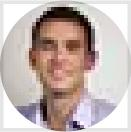

Image Summary:

Based on the image provided, here is a concise summary optimized for semantic retrieval:

* **Subject:** A highly pixelated, low-resolution circular profile picture (avatar) of a man.
* **Appearance:** The man appears to have short brown hair, light skin, and is wearing a light-colored collared shirt. 
* **Format:** The portrait is framed within a circular crop on a light gray background.


Image 2
File Name : figure-1-2.jpg


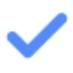

Image Summary:

A blue checkmark (tick mark) icon with rounded ends on a white background. This symbol commonly represents approval, correctness, verification, validation, success, or task completion.


Image 3
File Name : figure-10-12.jpg


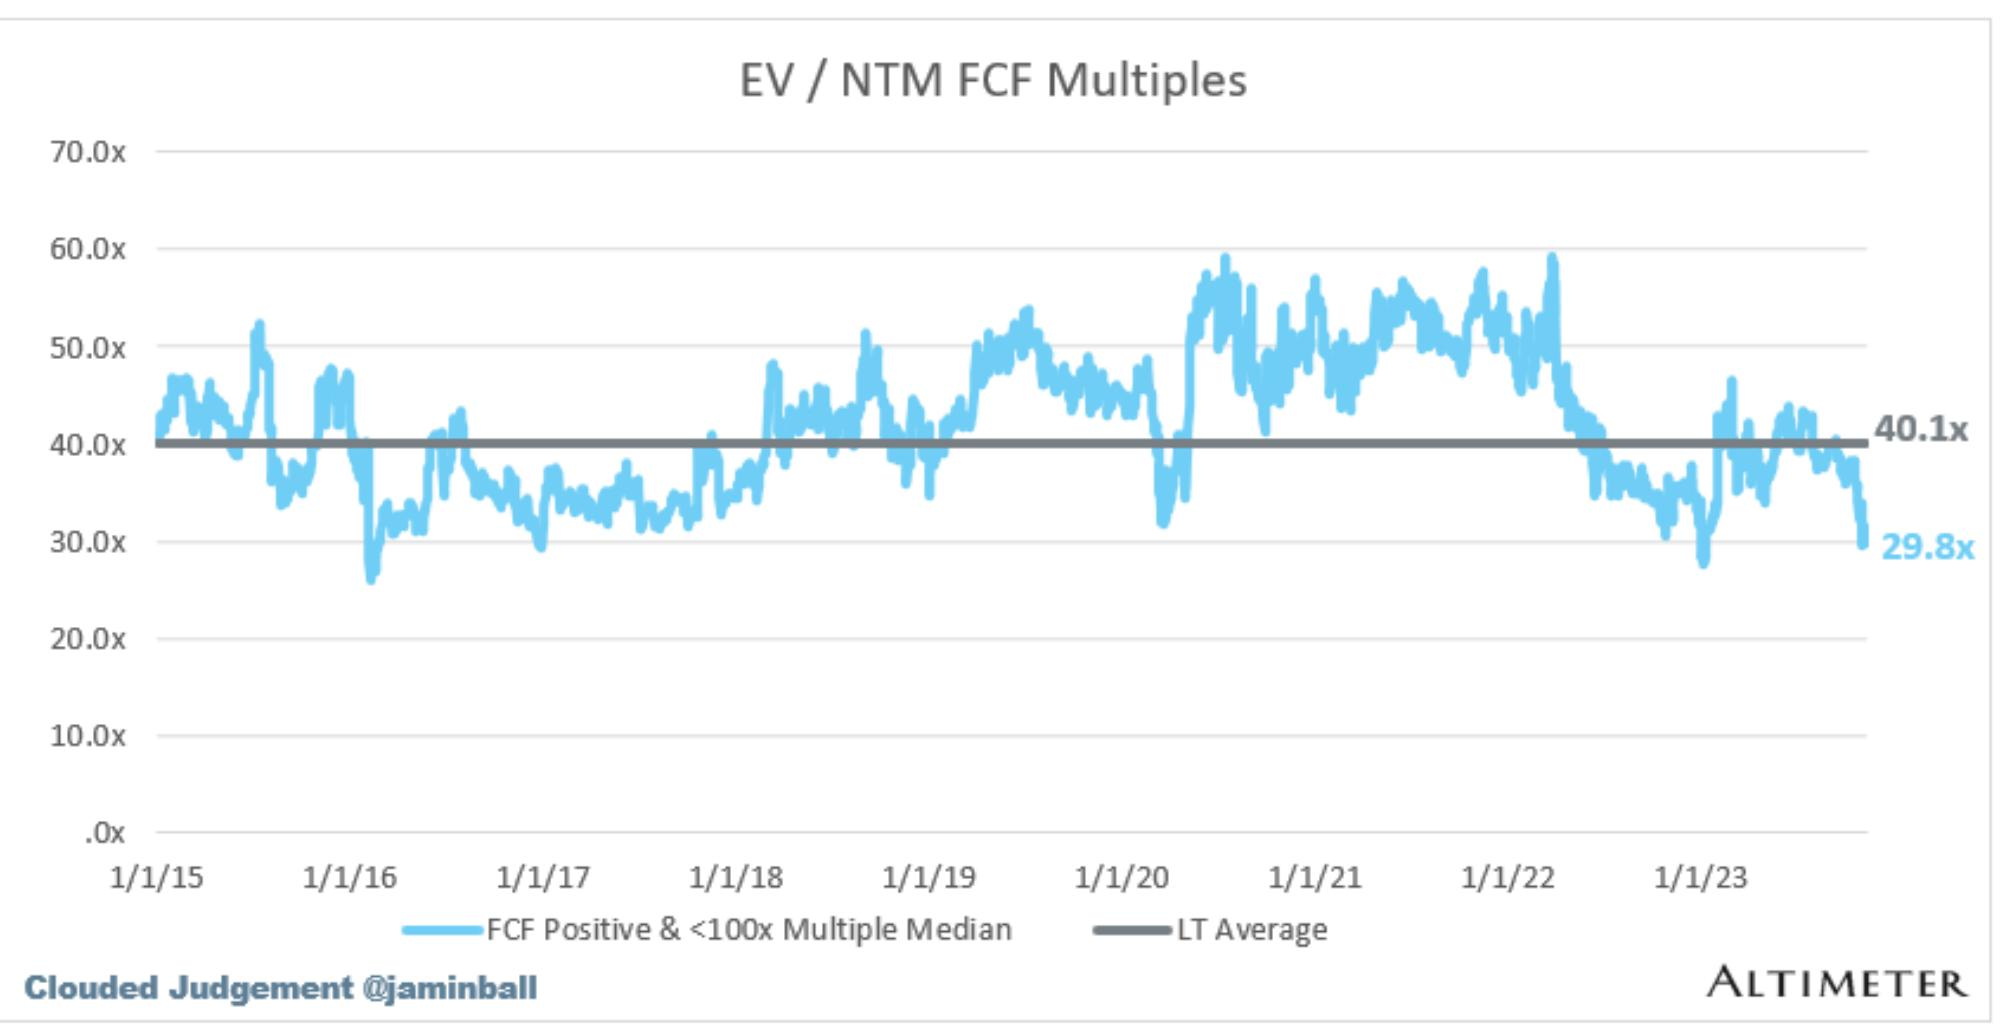

Image Summary:

Based on the image provided, here is a concise summary optimized for semantic retrieval:

### **Overview**
This is a financial line chart tracking **EV / NTM FCF Multiples** (Enterprise Value to Next Twelve Months Free Cash Flow Multiples) from January 1, 2015, through late 2023. 

### **Key Data Series & Values**
* **FCF Positive & <100x Multiple Median (Light Blue Line):** Tracks the fluctuating median valuation multiple over time. 
  * **Peak:** Reached near **60.0x** during late 2020 and early 2022.
  * **Final Value:** Ends at **29.8x** at the far right of the chart.
* **LT Average (Dark Gray Horizontal Line):** Represents the long-term average baseline, fixed at **40.1x**.

### **Key Relationship**
The final median multiple of **29.8x** is significantly below the historical long-term average of **40.1x**.

### **Metadata & Branding**
* **Title:** "EV / NTM FCF Multiples"
* **Footer Text:** "Clouded Judgement @jaminball" (left) and "ALTIMETER" (right).




In [53]:
# =============================================================================
# Display the First 3 Images Along with Their Generated Summaries
# =============================================================================

from IPython.display import Image, display

# Get all extracted JPG images
image_files = sorted(
    [
        file
        for file in os.listdir(EXTRACTED_DIR_1)
        if file.lower().endswith(".jpg")
    ]
)

# Display only the first 3 images
for index, image_name in enumerate(image_files[:3], start=1):

    # Complete path to the image
    image_path = os.path.join(EXTRACTED_DIR_1, image_name)

    print("=" * 100)
    print(f"Image {index}")
    print(f"File Name : {image_name}")
    print("=" * 100)

    # Display the extracted image
    display(Image(filename=image_path))

    # Display the AI-generated summary
    print("Image Summary:\n")
    print(image_summaries[index - 1])

    print("\n")

In [54]:
# =============================================================================
# Verify That Every Image Has a Summary
# =============================================================================

print(f"Images Found      : {len(image_base64_list)}")
print(f"Summaries Created : {len(image_summaries)}")

if len(image_base64_list) == len(image_summaries):
    print("✅ Every image has a corresponding summary.")
else:
    print("❌ Some images are missing summaries.")

Images Found      : 18
Summaries Created : 18
✅ Every image has a corresponding summary.


## 12. Build a multi vector retriever backed by Chroma

At this point there are three parallel sets of data for PDF 2: text blocks and their summaries, tables and their summaries, images and their summaries. A `MultiVectorRetriever` lets a search match against the short summaries (which embed well and search accurately) while still returning the original, full detail content (the raw text, raw table or raw base64 image) once a match is found.

Chroma is used here as a local, on disk vector database, so nothing needs to be installed beyond the Python package.


## 12. Build a Multi Vector Retriever Using Chroma

At this stage, we have generated three different types of summaries from the PDF.

* Text summaries
* Table summaries
* Image summaries

Each summary represents its corresponding original content in a concise form that is optimized for semantic search.

Instead of embedding the large original documents directly, we embed only these summaries. This produces better retrieval performance while reducing storage and computation.

The original text, tables, and images are stored separately inside an in memory document store. During retrieval, the vector database searches only the summaries, and once a relevant summary is found, the retriever returns the original content associated with that summary.

This approach is called **Multi Vector Retrieval** because multiple representations (text, tables, and images) are linked to their original documents through unique document IDs.

### Why use Chroma?

Chroma is an open source vector database that stores embeddings locally on your machine. It requires no cloud service or API key, making it an excellent choice for learning and developing RAG applications.

### Why use BAAI/bge-base-en-v1.5?

Instead of using paid embedding APIs, this notebook uses the **BAAI/bge-base-en-v1.5** embedding model from Hugging Face.

Advantages include:

* Completely free
* Runs locally
* Produces high quality embeddings
* Well suited for Retrieval Augmented Generation (RAG)
* No API key required

### Initialize the Embedding Model

In [59]:
# =============================================================================
# Import the Hugging Face Embedding Model
# =============================================================================
from langchain_community.embeddings import HuggingFaceEmbeddings

# =============================================================================
# Initialize the Embedding Model
# =============================================================================

# Load a free embedding model from Hugging Face.
# This model converts summaries into numerical vectors
# that can be stored inside the Chroma vector database.

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14248\4036748739.py:14: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  embedding_model = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 227.55it/s]


### Create the Multi Vector Retriever

In [60]:
# =============================================================================
# Create a Multi Vector Retriever
# =============================================================================

def create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    texts,
    table_summaries,
    tables,
    image_summaries,
    images,
):
    """
    Create a Multi Vector Retriever.

    The retriever stores:

    • AI generated summaries inside the vector database.
    • Original content inside an in memory document store.

    During retrieval, the summaries are searched first.
    Once a matching summary is found, the retriever returns
    the corresponding original content.
    """

    # Store the original documents in memory
    store = InMemoryStore()

    # Metadata key used to associate summaries with originals
    id_key = "doc_id"

    # Create the Multi Vector Retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )

    # ---------------------------------------------------------
    # Helper function to add summaries and original documents
    # ---------------------------------------------------------

    def add_documents(doc_summaries, doc_contents):

        # Generate a unique ID for every original document
        doc_ids = [
            str(uuid.uuid4())
            for _ in doc_contents
        ]

        # Create LangChain Document objects containing summaries
        summary_documents = [

            Document(
                page_content=summary,
                metadata={
                    id_key: doc_ids[index]
                },
            )

            for index, summary in enumerate(doc_summaries)

        ]

        # Store summary embeddings inside Chroma
        retriever.vectorstore.add_documents(
            summary_documents
        )

        # Store the original documents in memory
        retriever.docstore.mset(
            list(zip(doc_ids, doc_contents))
        )

    # ---------------------------------------------------------
    # Add each content type
    # ---------------------------------------------------------

    if text_summaries:
        add_documents(
            text_summaries,
            texts,
        )

    if table_summaries:
        add_documents(
            table_summaries,
            tables,
        )

    if image_summaries:
        add_documents(
            image_summaries,
            images,
        )

    return retriever

### Create the Chroma Vector Database

In [61]:
# =============================================================================
# Create the Chroma Vector Database
# =============================================================================

# Store all summary embeddings inside a local Chroma database.

vectorstore = Chroma(
    collection_name="multimodal_rag",
    embedding_function=embedding_model,
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14248\1521859209.py:7: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the langchain-chroma package and should be used instead. To use it run `pip install -U langchain-chroma` and import as `from langchain_chroma import Chroma`.
  vectorstore = Chroma(
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


### Build the Multi Vector Retriever

In [62]:
# =============================================================================
# Build the Multi Vector Retriever
# =============================================================================

retriever_multi_vector = create_multi_vector_retriever(
    vectorstore=vectorstore,

    text_summaries=text_summaries,
    texts=NarrativeText,

    table_summaries=table_summaries,
    tables=Table,

    image_summaries=image_summaries,
    images=image_base64_list,
)

print("Multi Vector Retriever created successfully.")

Multi Vector Retriever created successfully.


## 13. Display Images and Prepare Retrieved Content

After creating the Multi Vector Retriever, it is useful to understand how images are stored and retrieved.

Earlier in the notebook, every extracted image was converted into a **Base64 encoded string** before being stored inside the document store. Base64 is a text representation of binary image data, making it easy to store and pass images between different components of the RAG pipeline.

In this section, we will:

1. Convert Base64 strings back into images.
2. Display retrieved images inside the notebook.
3. Detect whether retrieved content is an image or plain text.
4. Resize images before sending them to the multimodal model.
5. Separate retrieved images and text so they can be processed correctly.

These helper functions will be used later when building the final Multimodal RAG pipeline.

### Import Required Libraries

In [ ]:
import io
import re
import base64

from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

### Display a Base64 Encoded Image

In [64]:
# =============================================================================
# Display a Base64 Encoded Image
# =============================================================================

def display_base64_image(img_base64):
    """
    Display a Base64 encoded image inside the notebook.

    Parameters
    ----------
    img_base64 : str
        Base64 encoded image.
    """

    html = f"""
    <img
        src="data:image/jpeg;base64,{img_base64}"
        width="700"
    />
    """

    display(HTML(html))

### Test the Display Function


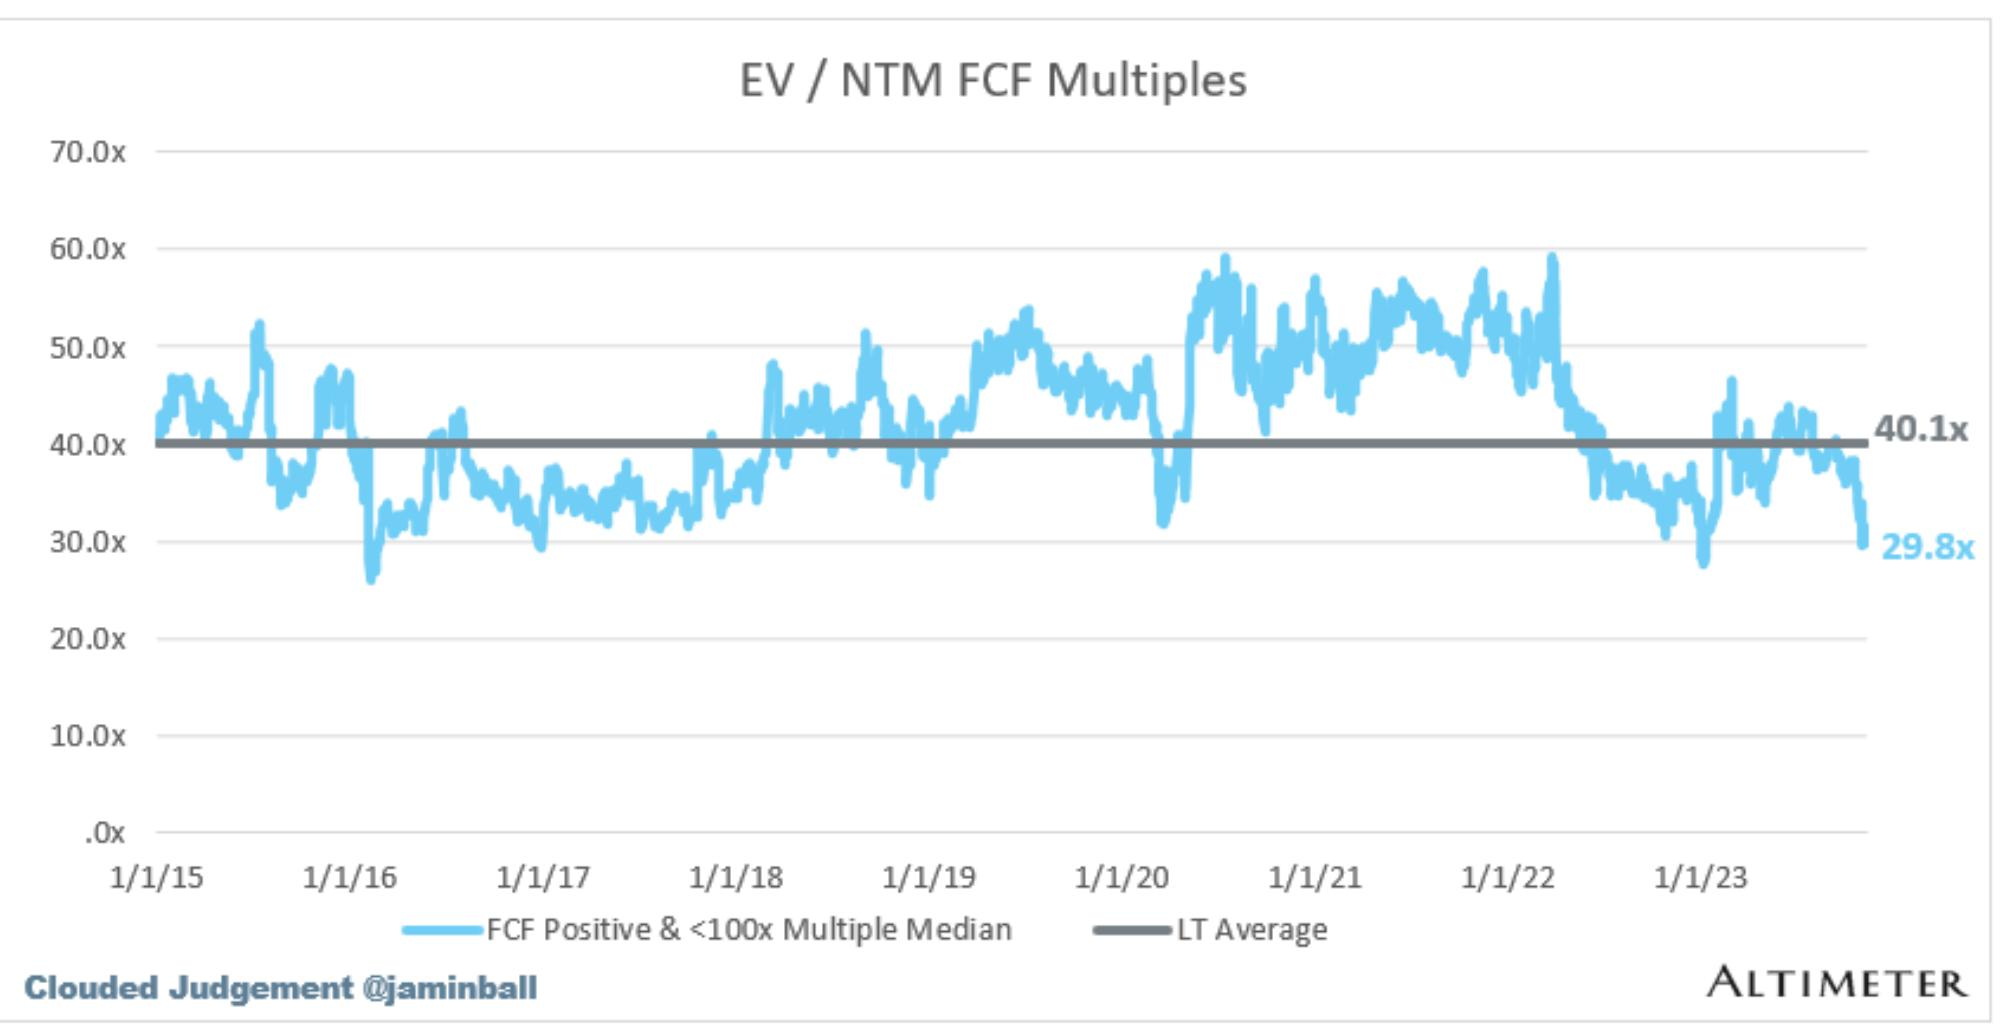

In [66]:
# =============================================================================
# Display One Retrieved Image
# =============================================================================

display_base64_image(image_base64_list[2])

### Display the Matching Image Summary

In [68]:
# =============================================================================
# Display the Corresponding Image Summary
# =============================================================================

print(image_summaries[2])

Based on the image provided, here is a concise summary optimized for semantic retrieval:

### **Overview**
This is a financial line chart tracking **EV / NTM FCF Multiples** (Enterprise Value to Next Twelve Months Free Cash Flow Multiples) from January 1, 2015, through late 2023. 

### **Key Data Series & Values**
* **FCF Positive & <100x Multiple Median (Light Blue Line):** Tracks the fluctuating median valuation multiple over time. 
  * **Peak:** Reached near **60.0x** during late 2020 and early 2022.
  * **Final Value:** Ends at **29.8x** at the far right of the chart.
* **LT Average (Dark Gray Horizontal Line):** Represents the long-term average baseline, fixed at **40.1x**.

### **Key Relationship**
The final median multiple of **29.8x** is significantly below the historical long-term average of **40.1x**.

### **Metadata & Branding**
* **Title:** "EV / NTM FCF Multiples"
* **Footer Text:** "Clouded Judgement @jaminball" (left) and "ALTIMETER" (right).


### Check Whether a String Looks Like Base64

In [69]:
# =============================================================================
# Check Whether a String Looks Like Base64
# =============================================================================

def looks_like_base64(data):
    """
    Determine whether a string appears to be Base64 encoded.

    Parameters
    ----------
    data : str

    Returns
    -------
    bool
    """

    return re.match(
        r"^[A-Za-z0-9+/]+={0,2}$",
        data,
    ) is not None

### Check Whether Base64 Data Represents an Image

In [70]:
# =============================================================================
# Check Whether Base64 Data Represents an Image
# =============================================================================

def is_image_data(base64_data):
    """
    Determine whether Base64 data represents an image.

    The function inspects the image file signature
    (also known as the magic bytes).

    Parameters
    ----------
    base64_data : str

    Returns
    -------
    bool
    """

    image_signatures = {

        b"\xFF\xD8\xFF": "JPEG",

        b"\x89PNG\r\n\x1a\n": "PNG",

        b"GIF8": "GIF",

        b"RIFF": "WEBP",

    }

    try:

        header = base64.b64decode(base64_data)[:8]

        for signature in image_signatures:

            if header.startswith(signature):

                return True

        return False

    except Exception:

        return False

### Resize a Base64 Image

In [71]:
# =============================================================================
# Resize a Base64 Encoded Image
# =============================================================================

def resize_base64_image(
    base64_string,
    size=(1300, 600),
):
    """
    Resize a Base64 encoded image.

    Resizing images before sending them to the multimodal model
    reduces memory usage and improves inference speed.

    Parameters
    ----------
    base64_string : str

    size : tuple

    Returns
    -------
    str
        Resized Base64 encoded image.
    """

    # Decode Base64 into bytes
    image_bytes = base64.b64decode(base64_string)

    # Open the image
    image = Image.open(io.BytesIO(image_bytes))

    # Resize the image
    resized_image = image.resize(
        size,
        Image.LANCZOS,
    )

    # Save into memory
    buffer = io.BytesIO()

    resized_image.save(
        buffer,
        format=image.format,
    )

    # Convert back into Base64
    return base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

### Separate Retrieved Images and Text

In [72]:
# =============================================================================
# Separate Retrieved Images and Text
# =============================================================================

def split_image_text_types(documents):
    """
    Separate retrieved documents into images and text.

    Images remain as Base64 strings.

    Text and tables remain as plain text.

    Parameters
    ----------
    documents : list

    Returns
    -------
    dict

    {
        "images": [...],
        "texts": [...]
    }
    """

    images = []

    texts = []

    for document in documents:

        # Extract text if the object is a LangChain Document
        if isinstance(document, Document):

            document = document.page_content

        # Check whether the document is an image
        if (
            looks_like_base64(document)
            and
            is_image_data(document)
        ):

            images.append(

                resize_base64_image(document)

            )

        else:

            texts.append(document)

    return {

        "images": images,

        "texts": texts,

    }

## 14. Generate the Final RAG Answer using Groq

After the Multi Vector Retriever retrieves the most relevant documents, the returned content consists of:

* Original text
* Original tables
* AI generated image summaries

Since every image has already been converted into a descriptive textual summary during the indexing stage, the final answer can be generated using a text-only language model.

In this notebook, **Groq** is used as the final reasoning model because it is fast, free to use, and well suited for Retrieval Augmented Generation (RAG).

### Pipeline

1. Retrieve relevant summaries from Chroma.
2. Return the original text, tables, and image summaries.
3. Combine everything into a single context.
4. Send the context and the user's question to Groq.
5. Generate the final answer.

### Initialize the Groq Language Model

In [80]:
# =============================================================================
# Initialize the Groq Language Model
# =============================================================================

from langchain_groq import ChatGroq

# Groq will generate the final answer using the retrieved context.

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0,
)

### Create the Retrieval Augmented Generation (RAG) Prompt

In [81]:
# =============================================================================
# Create the Retrieval Augmented Generation (RAG) Prompt
# =============================================================================

def build_rag_prompt(question, retrieved_context):
    """
    Build a prompt by combining the retrieved context
    with the user's question.

    Parameters
    ----------
    question : str
        User's question.

    retrieved_context : dict
        Dictionary containing retrieved text and image summaries.

    Returns
    -------
    str
        Prompt for the Groq language model.
    """

    # Combine all retrieved text into one context
    context = "\n\n".join(retrieved_context["texts"])

    prompt = f"""
You are an expert AI assistant for a Retrieval Augmented Generation (RAG) system.

Use ONLY the retrieved context below to answer the user's question.

The retrieved context may contain:

• Text
• Tables
• AI-generated image summaries

If the answer cannot be found in the retrieved context,
clearly state that the information is unavailable.

Retrieved Context:

{context}

User Question:

{question}

Provide a detailed, accurate, and well-structured answer.
"""

    return prompt

### Generate the Final Response using Groq

In [82]:
# =============================================================================
# Generate the Final Response using Groq
# =============================================================================

def generate_rag_response(question, retrieved_context):
    """
    Generate the final answer using the retrieved context.

    Parameters
    ----------
    question : str

    retrieved_context : dict

    Returns
    -------
    str
        Final answer generated by Groq.
    """

    # Build the prompt
    prompt = build_rag_prompt(
        question,
        retrieved_context,
    )

    # Send the prompt to Groq
    response = llm.invoke(prompt)

    return response.content

### Create the Complete Multimodal RAG Chain

In [83]:
# =============================================================================
# Build the Complete Multimodal RAG Pipeline
# =============================================================================

def multimodal_rag(query, retriever):
    """
    Complete Multimodal RAG pipeline.

    Steps

    1. Retrieve relevant documents.
    2. Separate retrieved images and text.
    3. Generate the final answer using Groq.
    """

    # Retrieve relevant documents
    retrieved_documents = retriever.invoke(query)

    # Separate retrieved images and text
    retrieved_context = split_image_text_types(
        retrieved_documents
    )

    # Generate the final answer
    response = generate_rag_response(
        question=query,
        retrieved_context=retrieved_context,
    )

    return response

### Ask a Question

In [84]:
# =============================================================================
# Ask a Question using the Multimodal RAG Pipeline
# =============================================================================

query = """
Explain the retrieved figure in detail.
"""

response = multimodal_rag(
    query,
    retriever_multi_vector,
)

print(response)

The retrieved context provides a description of a chart and some related calculations, but it does not include the actual figure. However, based on the provided information, I can explain the chart and calculations in detail.

**Chart Explanation:**

The chart displays the EV (Enterprise Value) to NTM (Next Twelve Months) revenue multiple divided by NTM consensus growth expectations. This chart aims to show how relatively cheap or expensive each stock is relative to their growth expectations.

To understand the chart, let's break down the components:

* EV / NTM revenue multiple: This is a valuation metric that compares a company's enterprise value to its revenue over the next 12 months.
* NTM consensus growth expectations: This refers to the expected growth rate of the company's revenue over the next 12 months, based on consensus estimates.

By dividing the EV / NTM revenue multiple by the NTM consensus growth expectations, the chart provides a normalized view of valuation relative to

### Try Another Example

In [85]:
# =============================================================================
# Ask Another Question
# =============================================================================

query = """
Why do we combine a pre-trained retriever with a
pre-trained sequence-to-sequence generator?
"""

response = multimodal_rag(
    query,
    retriever_multi_vector,
)

print(response)

## Combining Pre-trained Retriever and Sequence-to-Sequence Generator

The combination of a pre-trained retriever with a pre-trained sequence-to-sequence generator is a key architecture in Retrieval Augmented Generation (RAG) systems. This integration aims to leverage the strengths of both components to enhance performance across various natural language processing (NLP) tasks.

### Retriever Component

- **Functionality**: The retriever is designed to access and retrieve relevant information from a large corpus or database based on a given query. It plays a crucial role in finding contextually relevant information that can aid in generating accurate and informative responses.
- **Pre-training**: A pre-trained retriever has already been trained on a large dataset to learn effective representations of queries and documents. This pre-training enables the retriever to efficiently search through vast amounts of data to find relevant information.

### Sequence-to-Sequence Generator

- **Fun

### Display the Retrieved Documents

In [86]:
# =============================================================================
# Display the Retrieved Documents
# =============================================================================

retrieved_documents = retriever_multi_vector.invoke(query)

print(f"Retrieved {len(retrieved_documents)} document(s).")

Retrieved 4 document(s).


### Display the Retrieved Text

In [87]:
# =============================================================================
# Display the Retrieved Text
# =============================================================================

retrieved_context = split_image_text_types(
    retrieved_documents
)

print("=" * 100)

print("Retrieved Text\n")

print("=" * 100)

print("\n\n".join(retrieved_context["texts"]))

Retrieved Text

§3 Retriever §4 Retrieval Fusions §5 Generators §6 Tasks §7 Evaluation • Building the Retriever • Query-based Fusion • Architectural • Language Modeling • A Taxonomy of RAG • Chunking, Encoding • Logits-based Fusion Requirements • Machine Translation Evaluation • Building index/DB • Latent Fusion • Generator Types • Text Summarization • Key Evaluation • Querying the Retriever • Parametric Fusion • Impact of Generator • Question Answering Challenges • Encoding • Comparison of Design • Information Extraction • Comparison of • ANN Search Retrieval Fusions • Practical Guidelines for • Text Classification Evaluation • Post-processing • Hybrid Retrieval Fusion Selecting Generators • Dialogue System • Benchmark Limitations §8 RAG Training and KB Update §9 Applications §10 Discussion and Future Directions • RAG without Knowledge Base Update • RAG in Industry • Security and Privacy • RAG vs. Long-Context • Training Retriever • Frameworks and Considerations for RAG LLMs • Trainin

### Display the Retrieved Images

In [89]:
# =============================================================================
# Display the Retrieved Images
# =============================================================================

for index, image in enumerate(
    retrieved_context["images"],
    start=1,
):

    print("=" * 100)
    print(f"Retrieved Image {index}")
    print("=" * 100)

    display_base64_image(image)

# Conclusion

In this project, we built a complete **Multimodal Retrieval Augmented Generation (Multimodal RAG)** system capable of understanding and retrieving information from **text, tables, and images** contained within PDF documents.

Instead of embedding the original PDF directly, the document is first partitioned into its individual components. Each content type is then processed independently to generate concise summaries optimized for semantic retrieval.

The extracted text and tables are summarized using **Groq**, while extracted images are analyzed and summarized using **Google Gemini**. These summaries are converted into vector embeddings using the **BAAI/bge-base-en-v1.5** embedding model and stored inside a local **Chroma** vector database. At the same time, the original text, tables, and images are preserved inside an **InMemoryStore**, allowing the retriever to return the complete original content.

When a user submits a query, the **Multi Vector Retriever** searches the embedded summaries and retrieves the corresponding original text, tables, and image summaries. The retrieved context is then combined into a single prompt and sent to **Groq**, which generates the final Retrieval Augmented Generation (RAG) response.

This architecture combines the strengths of multiple AI models and open-source tools:

* **Groq** generates fast summaries for text and tables and produces the final RAG answer.
* **Google Gemini** understands images and generates descriptive image summaries during the indexing stage.
* **BAAI/bge-base-en-v1.5** creates high-quality embeddings locally without requiring a paid API.
* **Chroma** stores and searches vector embeddings efficiently.
* **LangChain** orchestrates the retrieval pipeline and Multi Vector Retriever.

The result is a scalable, efficient, and cost-effective Multimodal RAG system capable of answering complex questions using information extracted from text, tables, and images within PDF documents.

### Tools and Technologies Used

# Tools and Technologies Used

| Tool / Library | Purpose |
|----------------|---------|
| **Unstructured** | Extract text, tables, images, titles, headers, and other elements from PDF documents. |
| **Groq** | Generate summaries for text and tables, and produce the final RAG response. |
| **Google Gemini** | Analyze extracted images and generate image summaries during indexing. |
| **BAAI/bge-base-en-v1.5** | Generate semantic embeddings for text, table, and image summaries. |
| **Chroma** | Store and search vector embeddings locally. |
| **LangChain** | Build the retrieval pipeline and Multi Vector Retriever. |
| **MultiVectorRetriever** | Search summary embeddings while returning the original document content. |
| **InMemoryStore** | Store the original text, tables, and Base64 encoded images. |
| **Sentence Transformers** | Load and run the BAAI embedding model locally. |
| **Pillow (PIL)** | Read, resize, and process extracted images. |
| **Python** | Implement the complete Multimodal RAG pipeline. |
| **Base64 Encoding** | Convert images into text format for storage and retrieval. |
| **UUID** | Generate unique identifiers linking summaries with original documents. |
| **VS Code + Jupyter Notebook** | Develop, execute, and test the project locally. |

### Overall Project Flow

# Overall Project Workflow

```text
                          PDF Document
                               │
                               ▼
                Unstructured Document Parser
                               │
        ┌──────────────────────┼──────────────────────┐
        │                      │                      │
        ▼                      ▼                      ▼
      Text                  Tables                Images
        │                      │                      │
        ▼                      ▼                      ▼
   Groq Summary          Groq Summary        Gemini Summary
        │                      │                      │
        └───────────────┬──────┴──────────────┬──────┘
                        ▼
         BAAI/bge-base-en-v1.5 Embeddings
                        │
                        ▼
             Local Chroma Vector Database
                        │
                        ▼
              Multi Vector Retriever
                        │
            Search Summary Embeddings
                        │
                        ▼
 Retrieve Original Text, Tables and Image Summaries
                        │
                        ▼
          Combine Retrieved Context into Text
                        │
                        ▼
                 Groq Language Model
                        │
                        ▼
                Final Answer to the User
```